## State Estimation (With data from publicly available dataset Leg-KILO)

https://github.com/ouguangjun/legkilo-dataset

Not existing:
- contact_forces (maybe in joint_foot last 4 of effort)
- contact_state (can be estimated as contact_state = force > threshold)

Interesting topics:
- **/high_state** - contains position and velocity estimation of unitree, orientation and joint information

I checked that the values in the topics are equal, so I can work only with `high_state`. Since the values in `/high_state` and `/state_SDK` for position and velocity are equal, and `/state_SDK` is in an initial odom frame, it needs to be rotated to the world frame. These values can be used as a comparison between my estimation and the ones provided by unitree.

In [1]:
%load_ext autoreload
%autoreload 2

In [64]:
from utils.kf_utils import *
from utils.legkilo_reader import *
from utils.plot_data import *
from utils.run_estimation import run_state_estimation

#### Read ROS and Ground truth file

In [65]:
legkilo_reader = LegKILOReader(rosbag_path="../custom_datasets/corridor.bag",
                               gt_path="../custom_datasets/corridor_tum.txt",
                               output_dir="../results/leg-kilo",
                               file_name="legkilo-data_corridor-v2",
                               read_again=True)

legkilo_reader.inspect_rosbag_file(check_topic_eq=False)

Reading ground truth from ../custom_datasets/corridor_tum.txt
Reading rosbag data from ../custom_datasets/corridor.bag


Reading ROS .bag file: 100%|██████████| 670538/670538 [00:20<00:00, 32530.10it/s]


Converting base pos from odom frame to world frame.
Converting base vel from odom frame to world frame.
Saved data in: ../results/leg-kilo
============================== Topics ==============================
/high_state                               unitree_legged_msgs/msg/HighState
/state_SDK                                nav_msgs/msg/Odometry
/imu_raw                                  sensor_msgs/msg/Imu
/points_raw                               sensor_msgs/msg/PointCloud2

==================== Example for /high_state (unitree_legged_msgs/msg/HighState) ====================
stamp.sec = 1684325646
stamp.nanosec = 562455592
stamp.__msgtype__ = builtin_interfaces/msg/Time
head = [254 239]
levelFlag = 238
frameReserve = 0
SN = [100729604     66077]
version = [    590080 2146969345]
bandWidth = 250
imu.quaternion = [-0.01335226  0.01234161 -0.7031739   0.71078545]
imu.gyroscope = [-0.00191184 -0.01583053 -0.00426268]
imu.accelerometer = [ 1.1971008e-03 -3.1723171e-01  9.6558151e+00]
imu.r

## State Estimation

In [97]:
start = 0
end = 10000
leg_kilo_data = legkilo_reader.legkilo_data

mean_dt = np.round(np.mean(leg_kilo_data["dt"][start:end]), 4)
leg_kilo_data = legkilo_reader.legkilo_data
results_leg_kilo_est = run_state_estimation(dt=mean_dt,
                                            base_orient=leg_kilo_data['base_orient_quat'][start:end],
                                            base_ang_vel=leg_kilo_data['base_ang_vel'][start:end],
                                            joint_pos=leg_kilo_data['joint_pos'][start:end],
                                            joint_vel=leg_kilo_data['joint_vel'][start:end],
                                            joint_acc=leg_kilo_data["joint_acc"][start:end],
                                            joint_torque=leg_kilo_data['joint_torque'][start:end], # use torque and contact state to estimate contact force
                                            contact_forces=leg_kilo_data['foot_force'][start:end], # use singular force value to estimate contact state
                                            Q=[0.0001, 0.0001, 0.0001, 0.001],
                                            R=[0.01, 0.1, 0.0001, 0.001],
                                            L1=100,
                                            L2=10000,
                                            contact_state_threshold=200,
                                            model_name="go1",
                                            est_mode=4)

/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Running state estimation:   1%|          | 110/10000 [00:00<00:18, 549.37it/s]

Estimating contact state based on threshold
Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 10000/10000 [00:13<00:00, 757.09it/s]


### Position

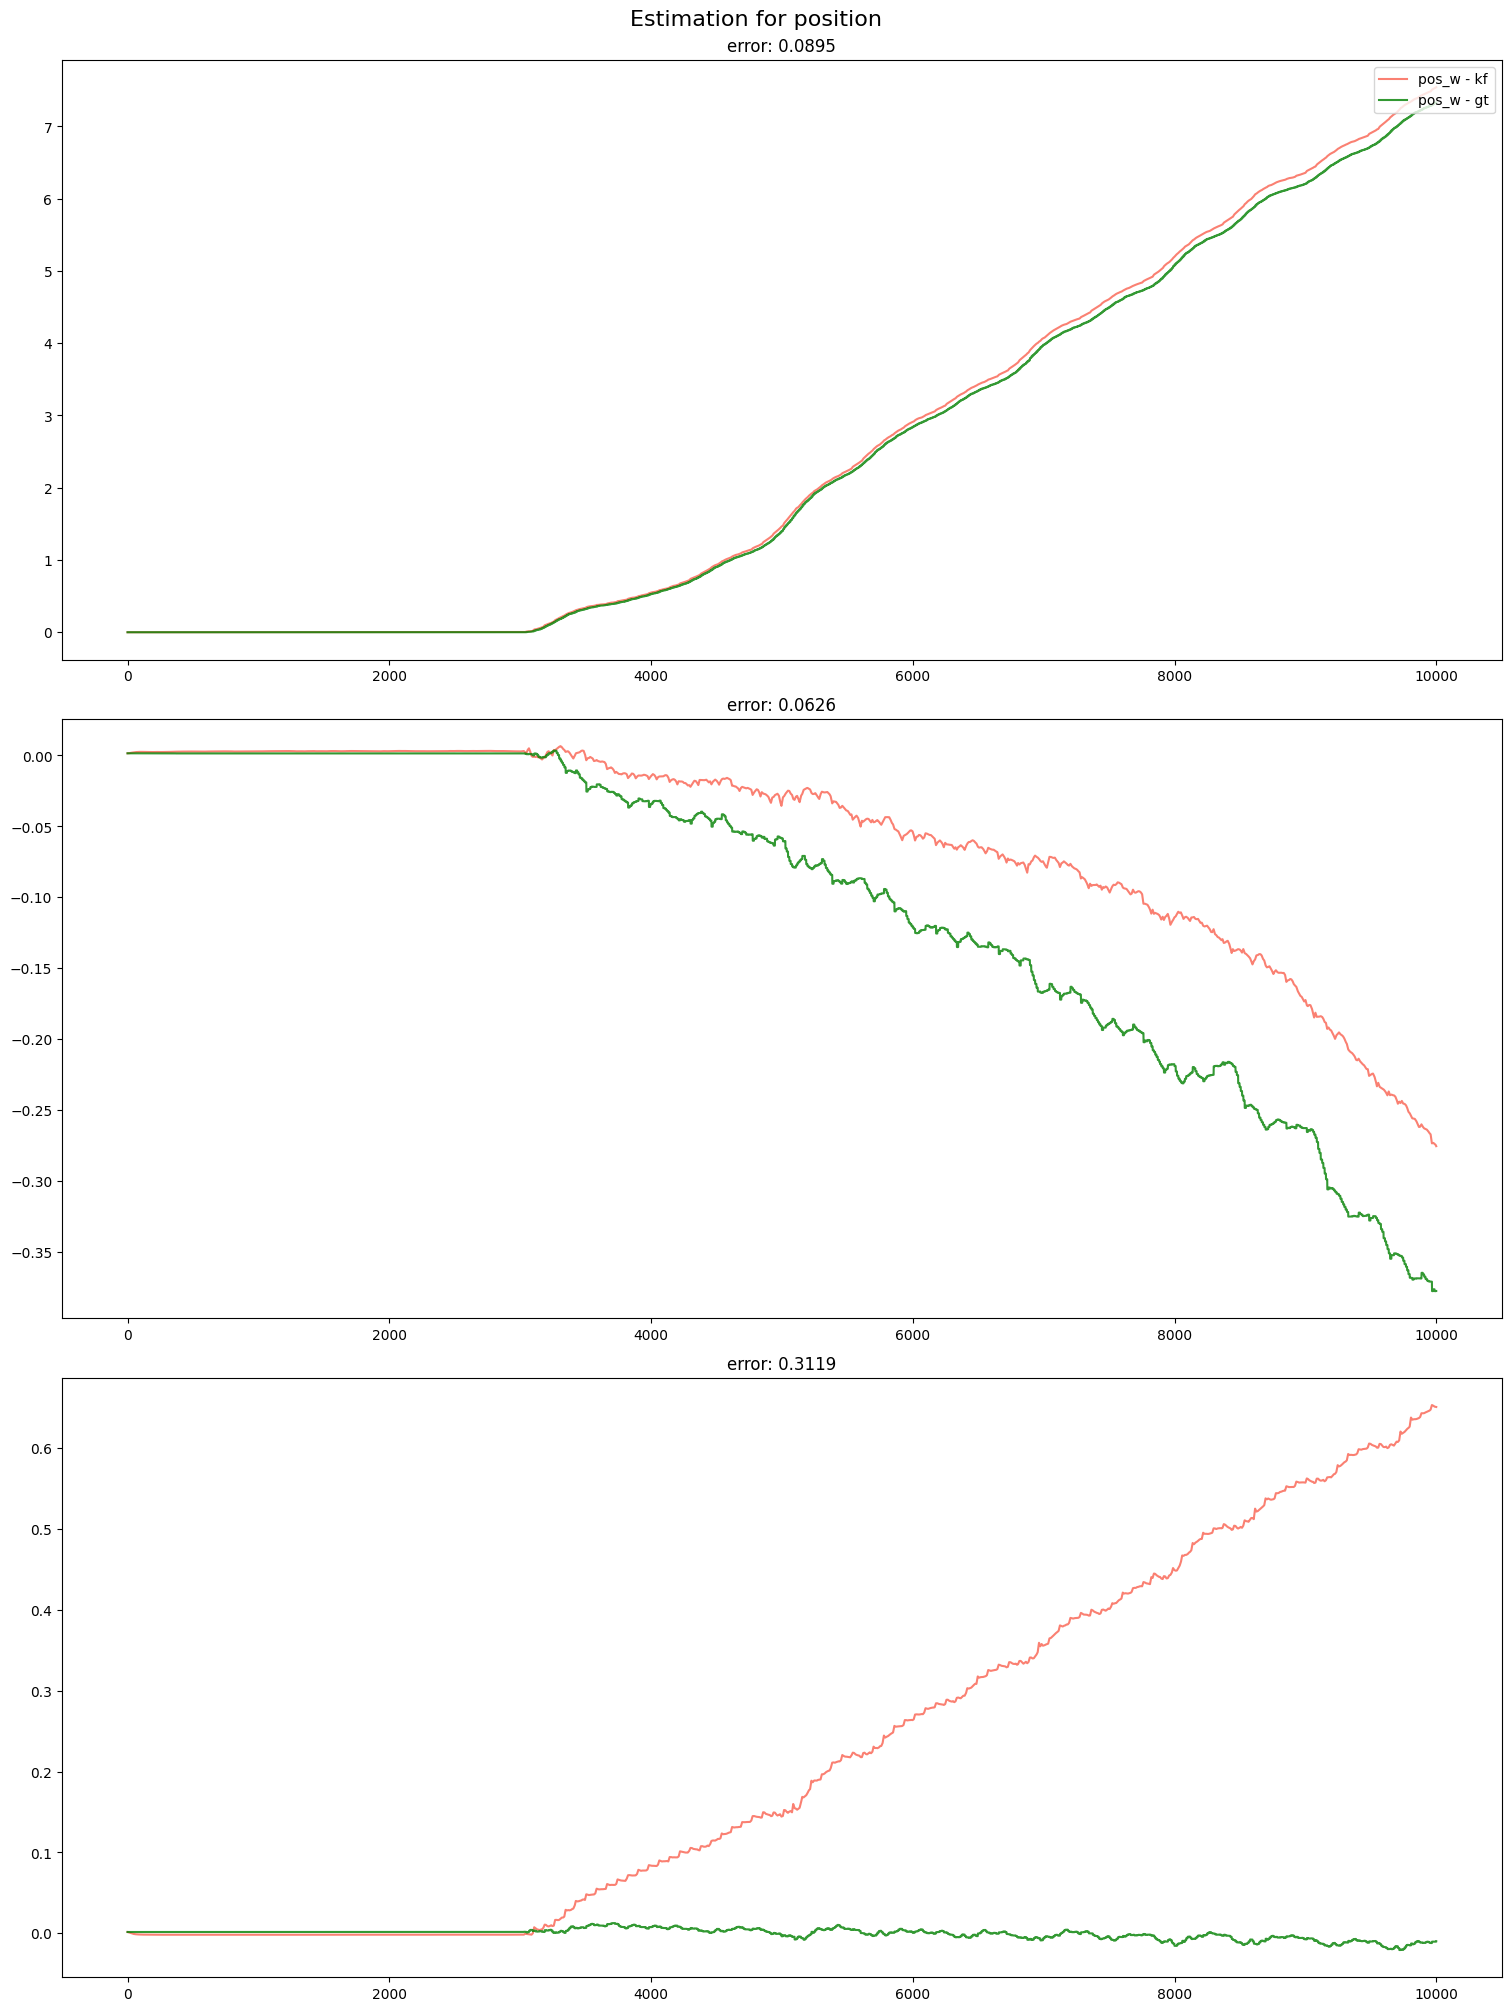

In [98]:
kf_pos_w = legkilo_reader.convert_odom_to_map(
    odom_data=results_leg_kilo_est["pos_update"],
    first_quat=leg_kilo_data['base_orient_quat'][start],
    with_offset=True
)

estimation_plot(gt_value=leg_kilo_data["base_pos_w"][start:end],
                est_value=kf_pos_w,
                label="pos_w",
                title="Estimation for position")

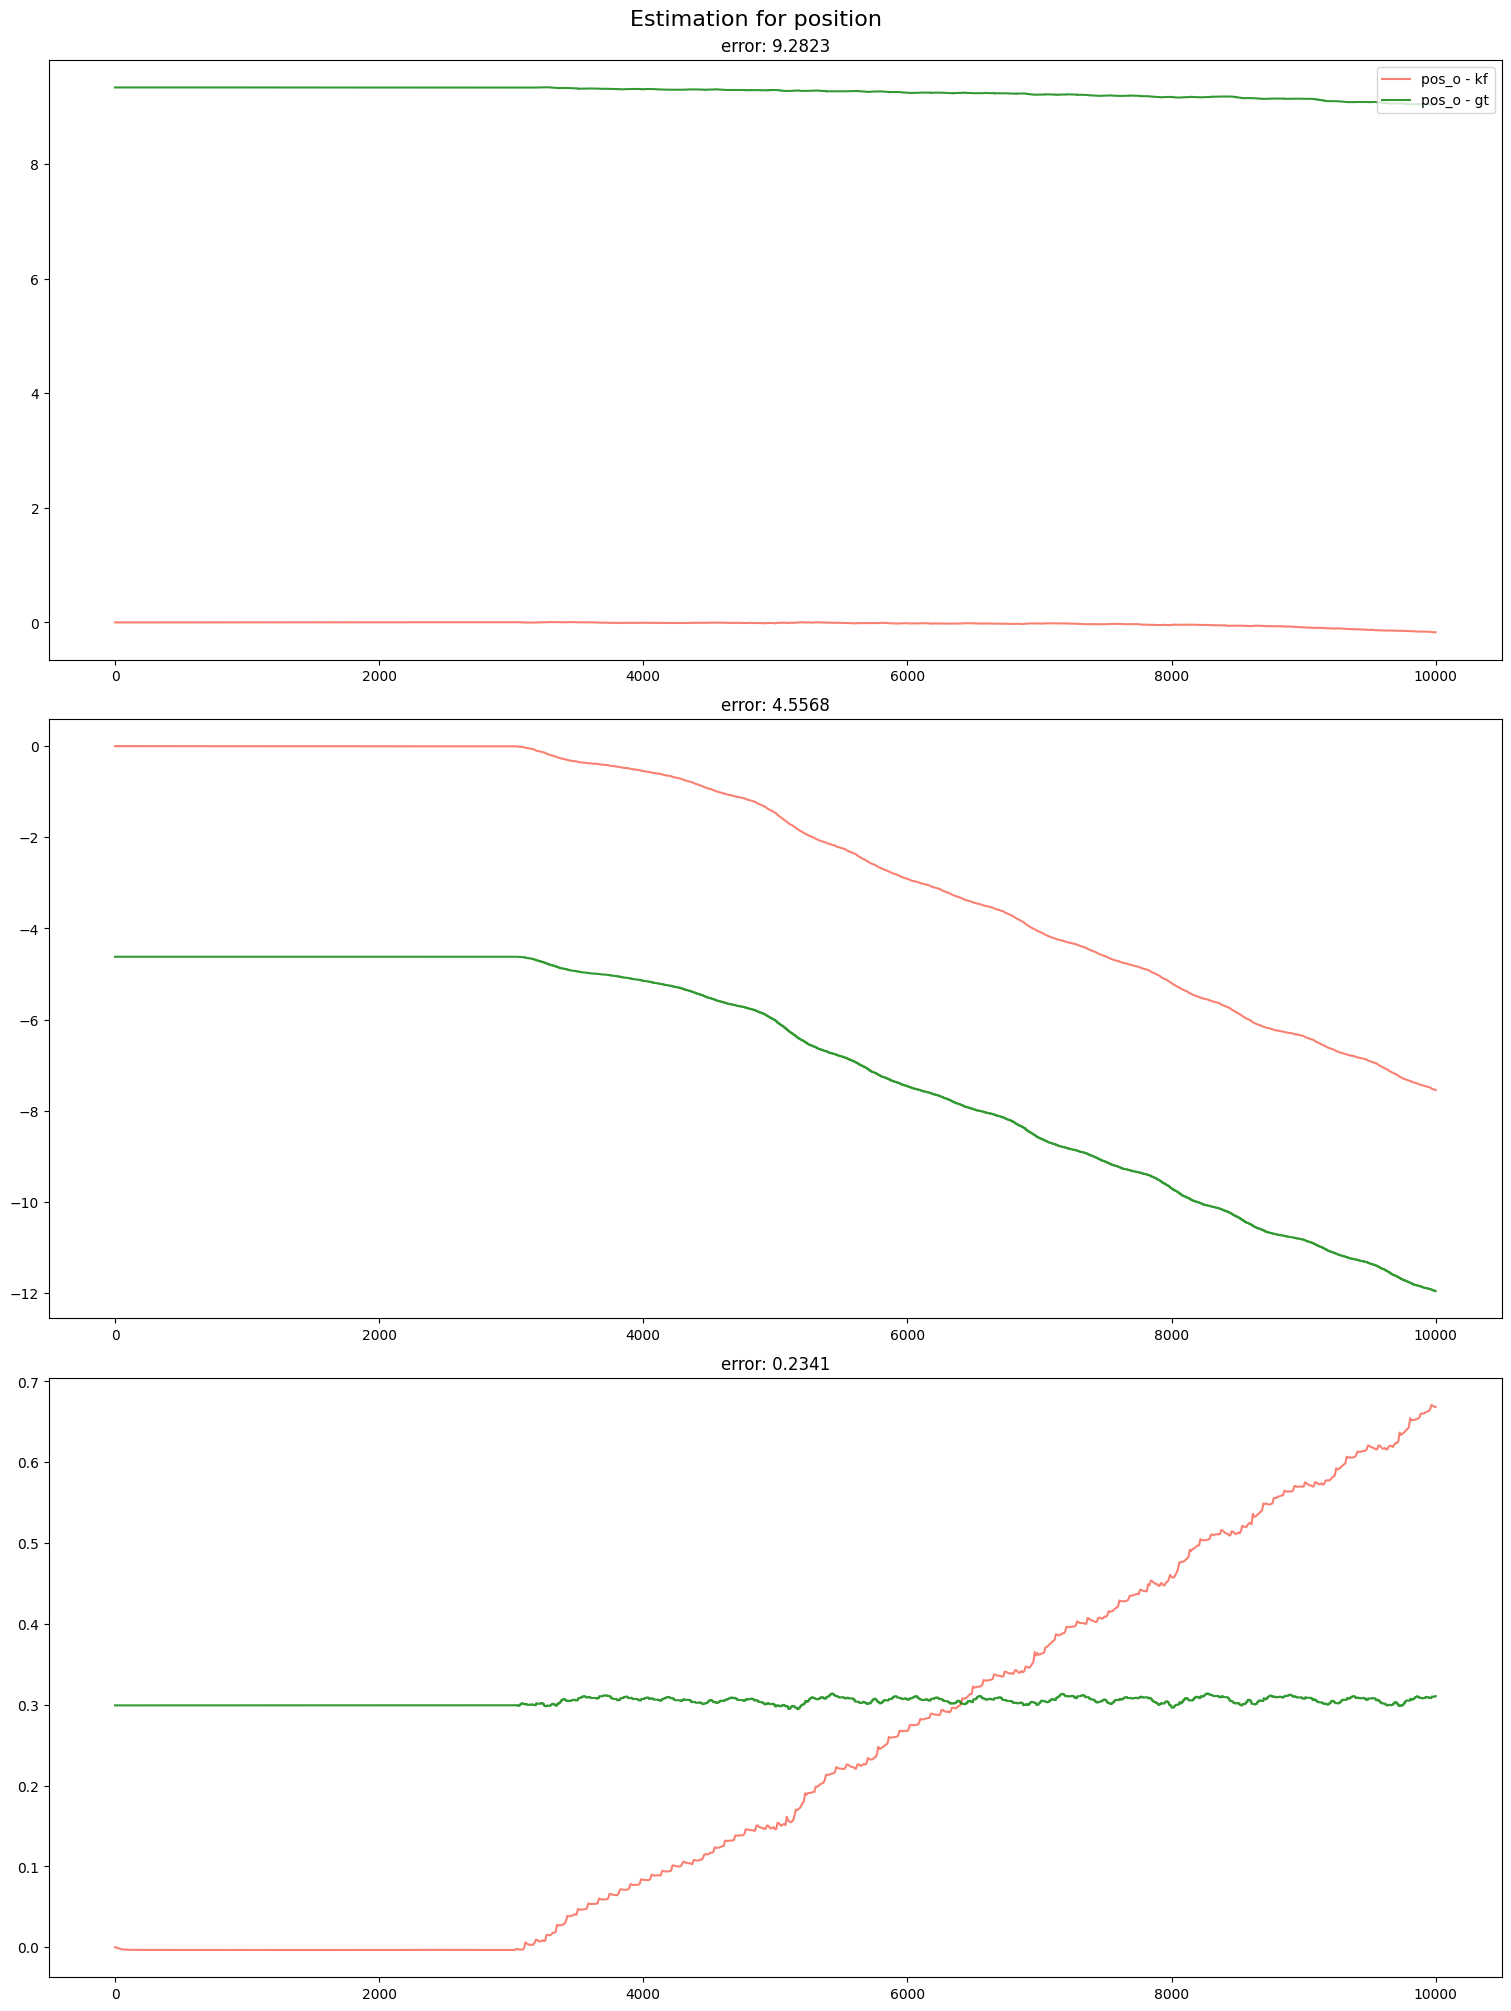

In [99]:
estimation_plot(gt_value=leg_kilo_data["base_pos_o"][start:end],
                est_value=results_leg_kilo_est["pos_update"],
                label="pos_o",
                title="Estimation for position")

### Linear Velocity

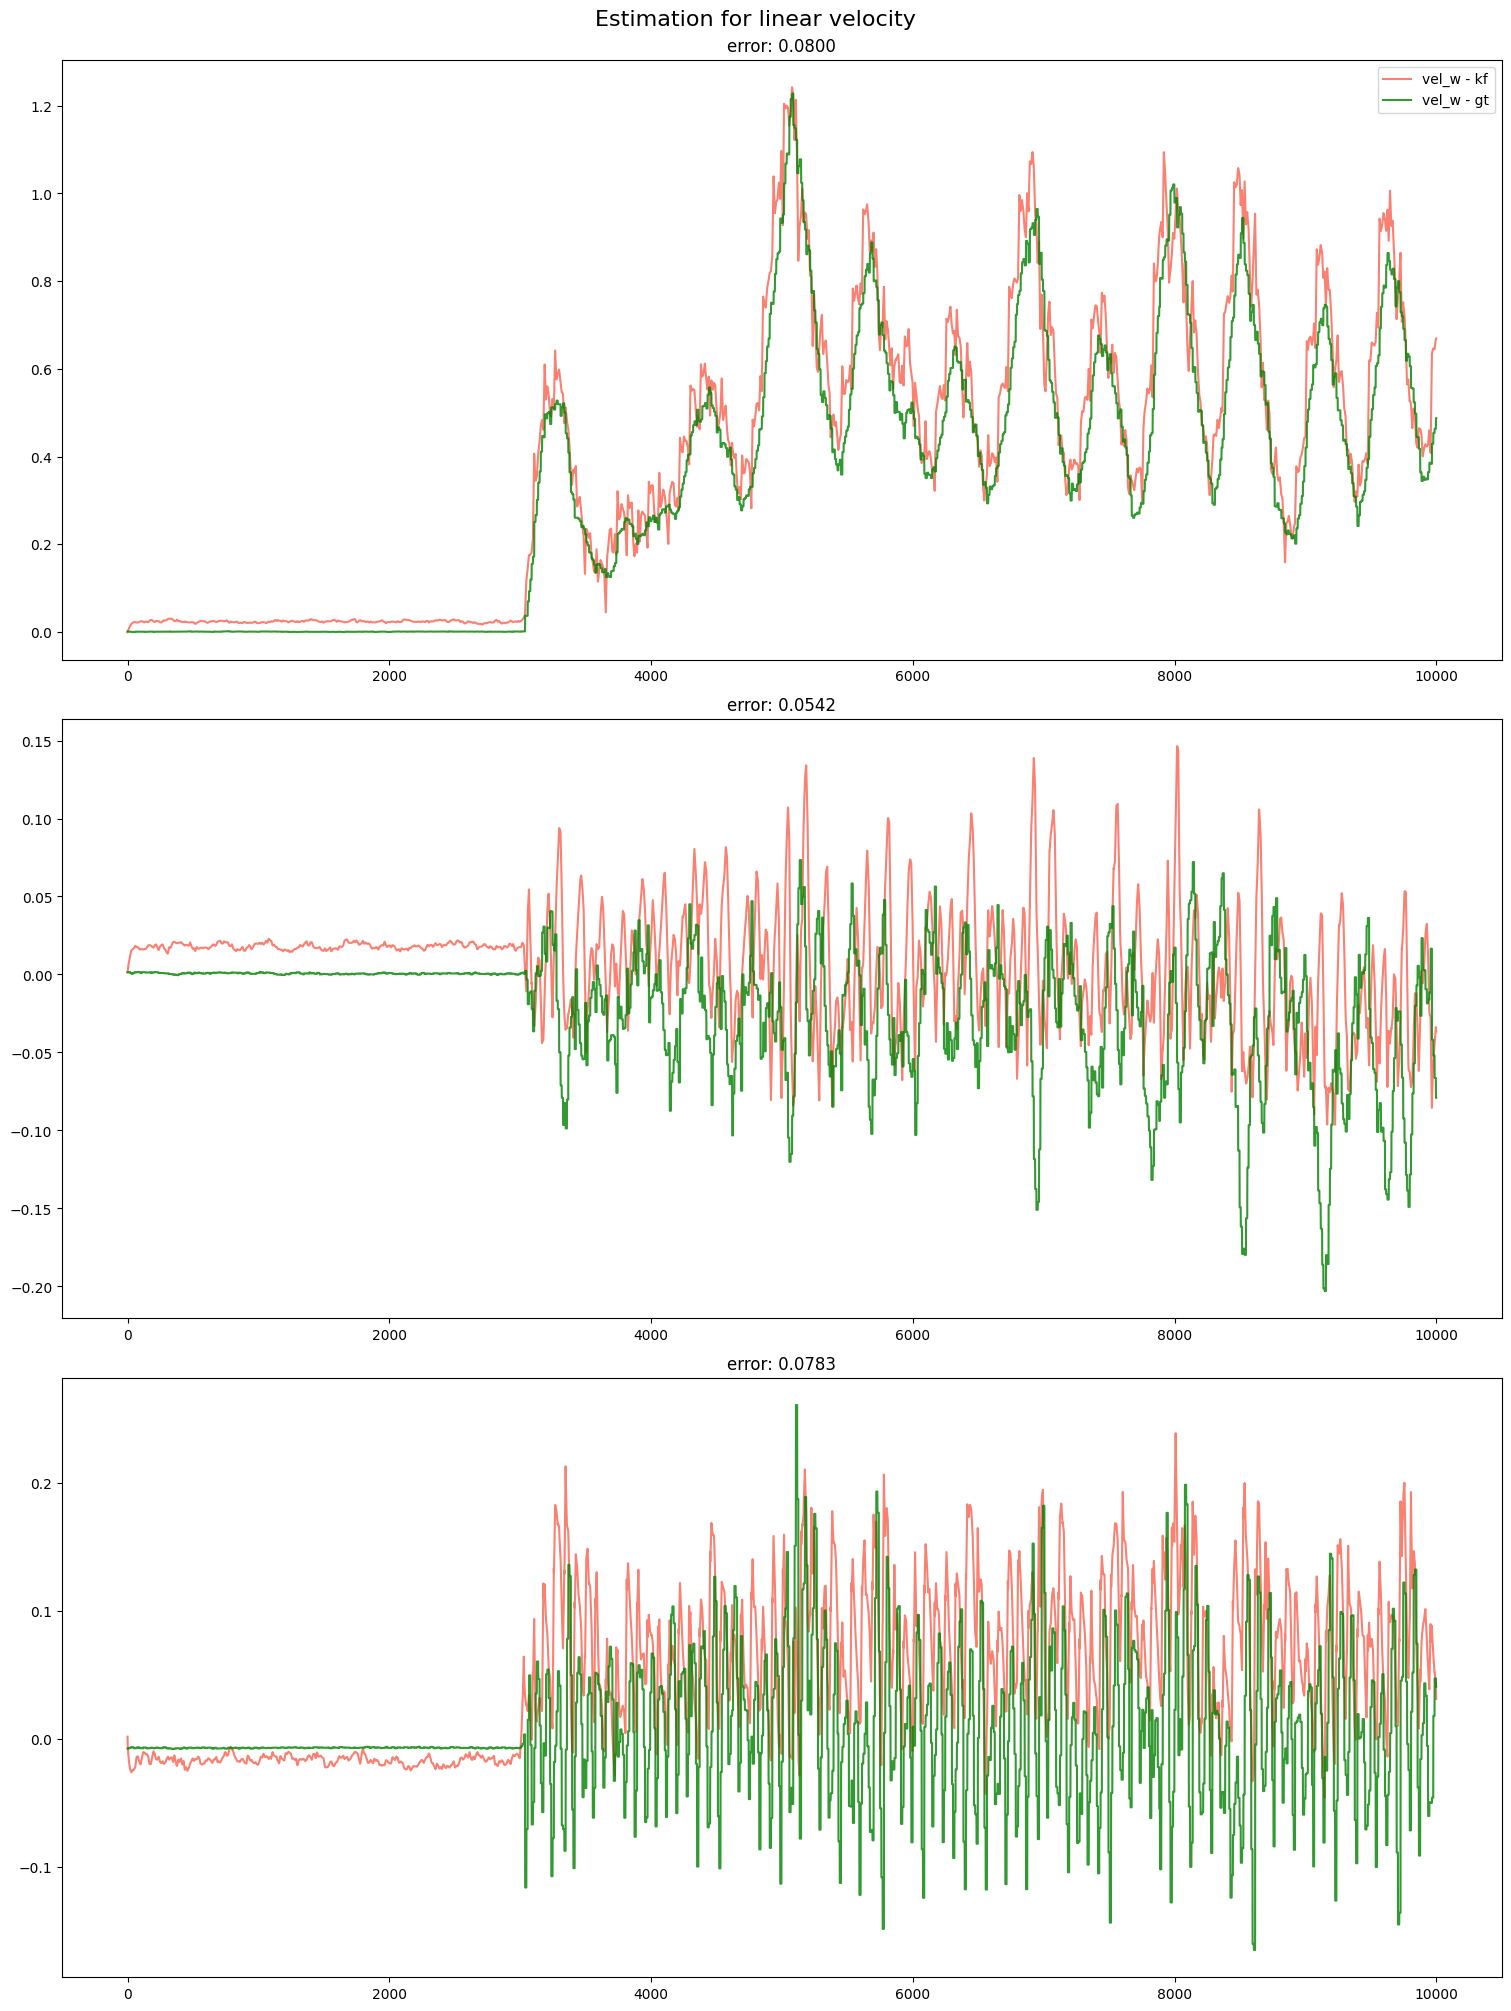

In [92]:
kf_vel_w = legkilo_reader.convert_odom_to_map(
    odom_data=results_leg_kilo_est["vel_update"],
    first_quat=leg_kilo_data['base_orient_quat'][start],
    with_offset=True
)

estimation_plot(gt_value=leg_kilo_data["base_vel_w"][start:end],
                est_value=kf_vel_w,
                label="vel_w",
                title="Estimation for linear velocity")

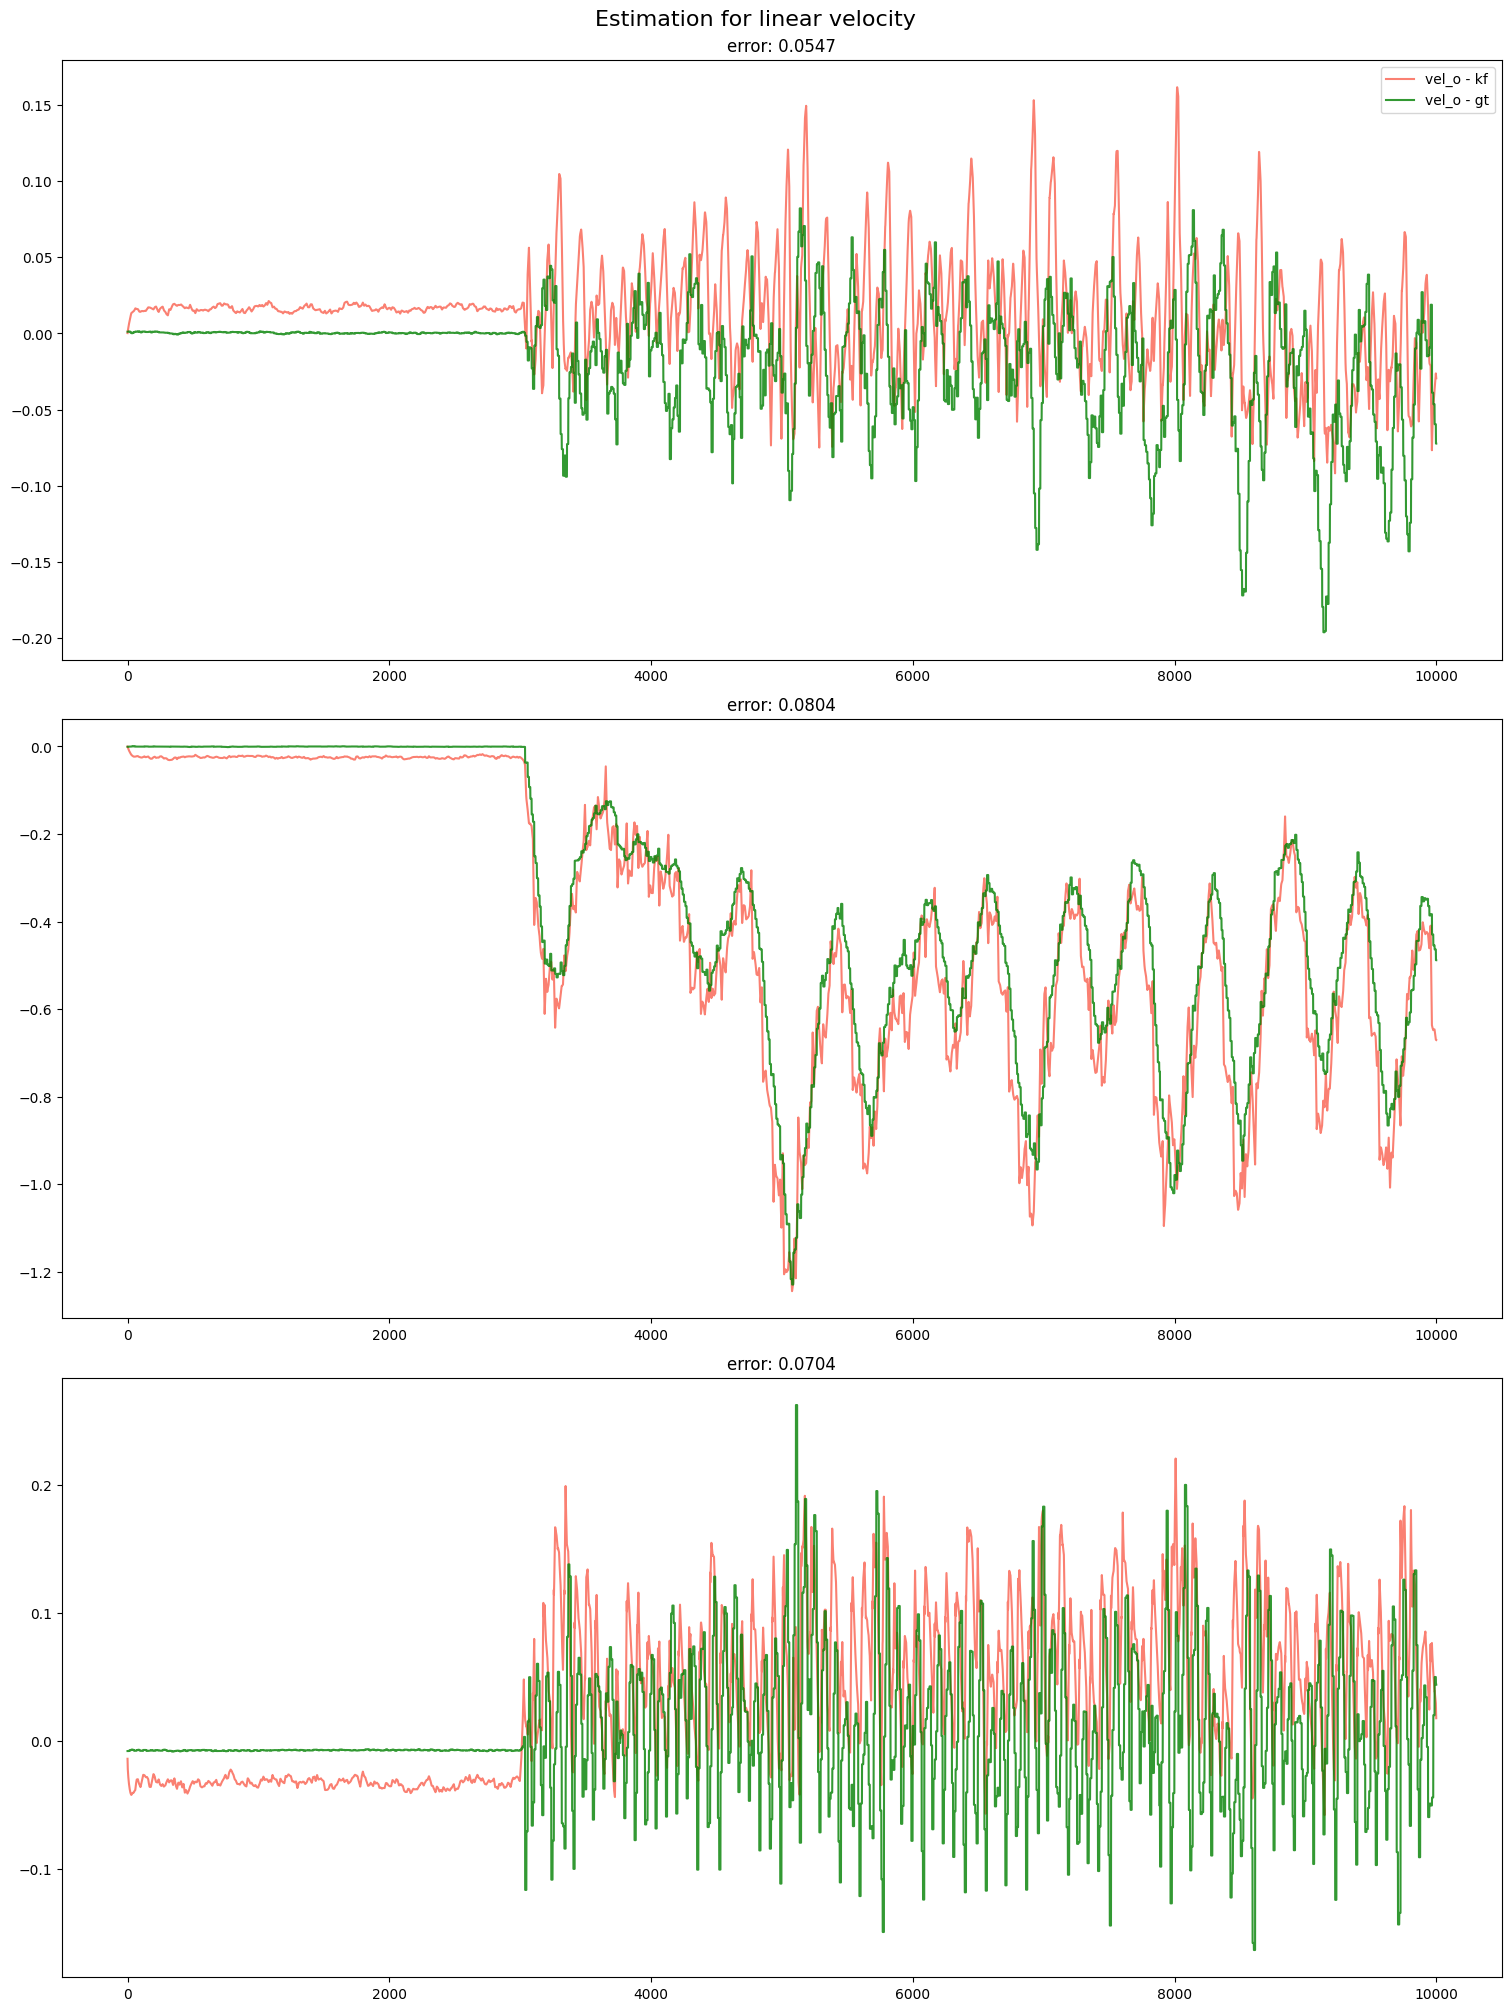

In [96]:
estimation_plot(gt_value=leg_kilo_data["base_vel_o"][start:end],
                est_value=results_leg_kilo_est["vel_update"],
                label="vel_o",
                title="Estimation for linear velocity")

### Angular Velocity

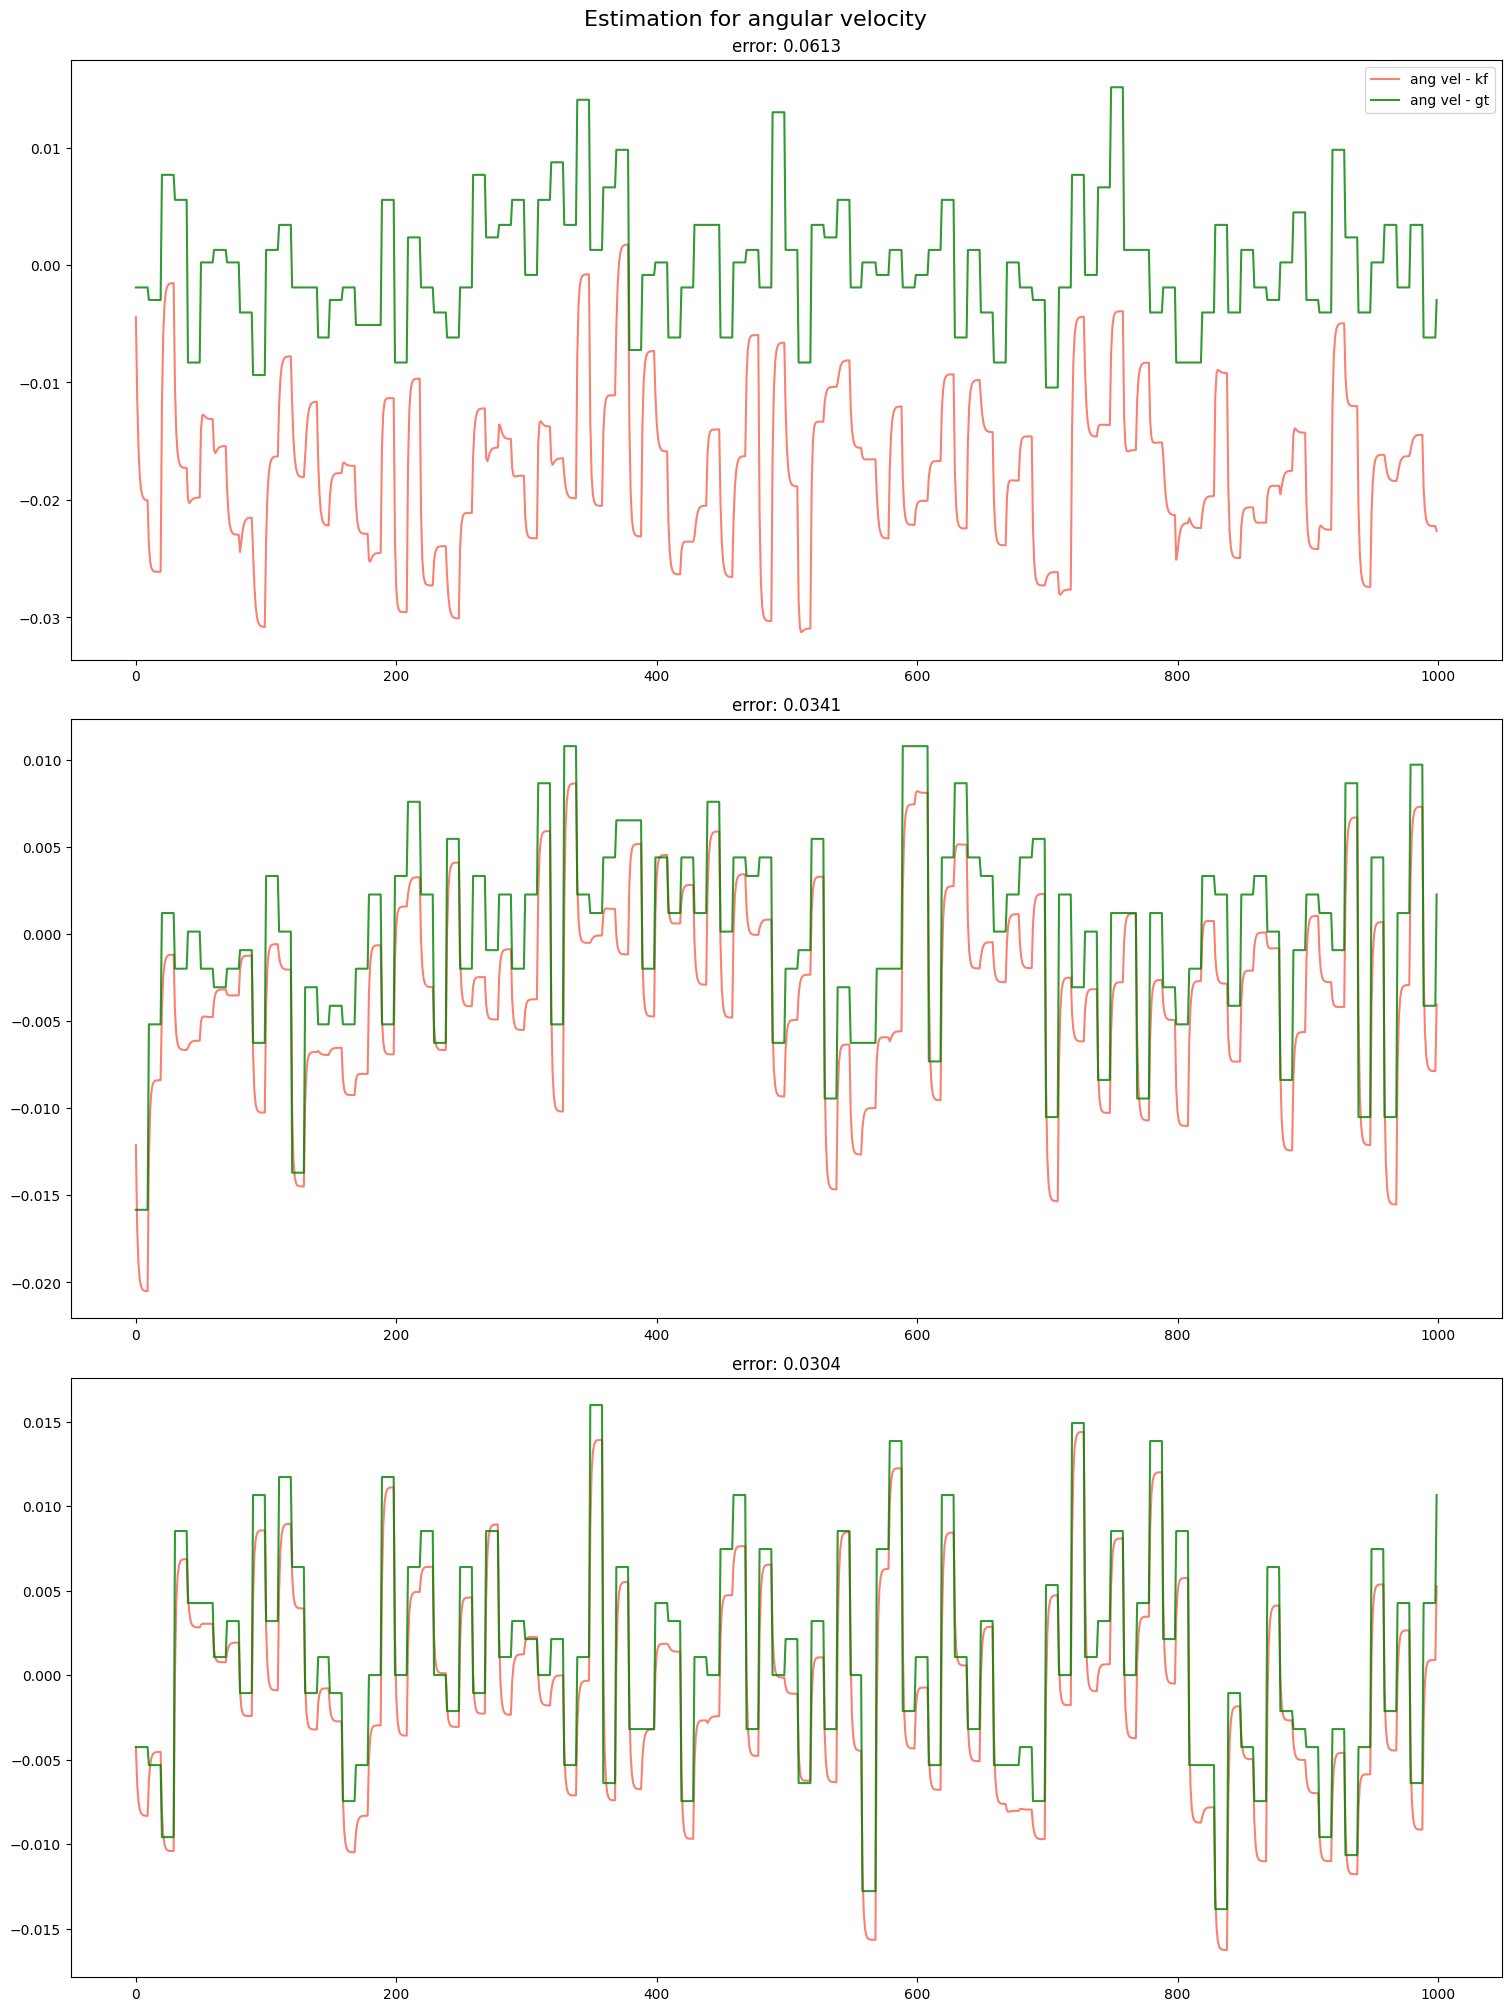

In [86]:
estimation_plot(gt_value=leg_kilo_data["base_ang_vel"][start:end],
                est_value=results_leg_kilo_est["ang_vel_update"],
                label="ang vel",
                start=0,
                end=1000,
                title="Estimation for angular velocity")

### Contact force

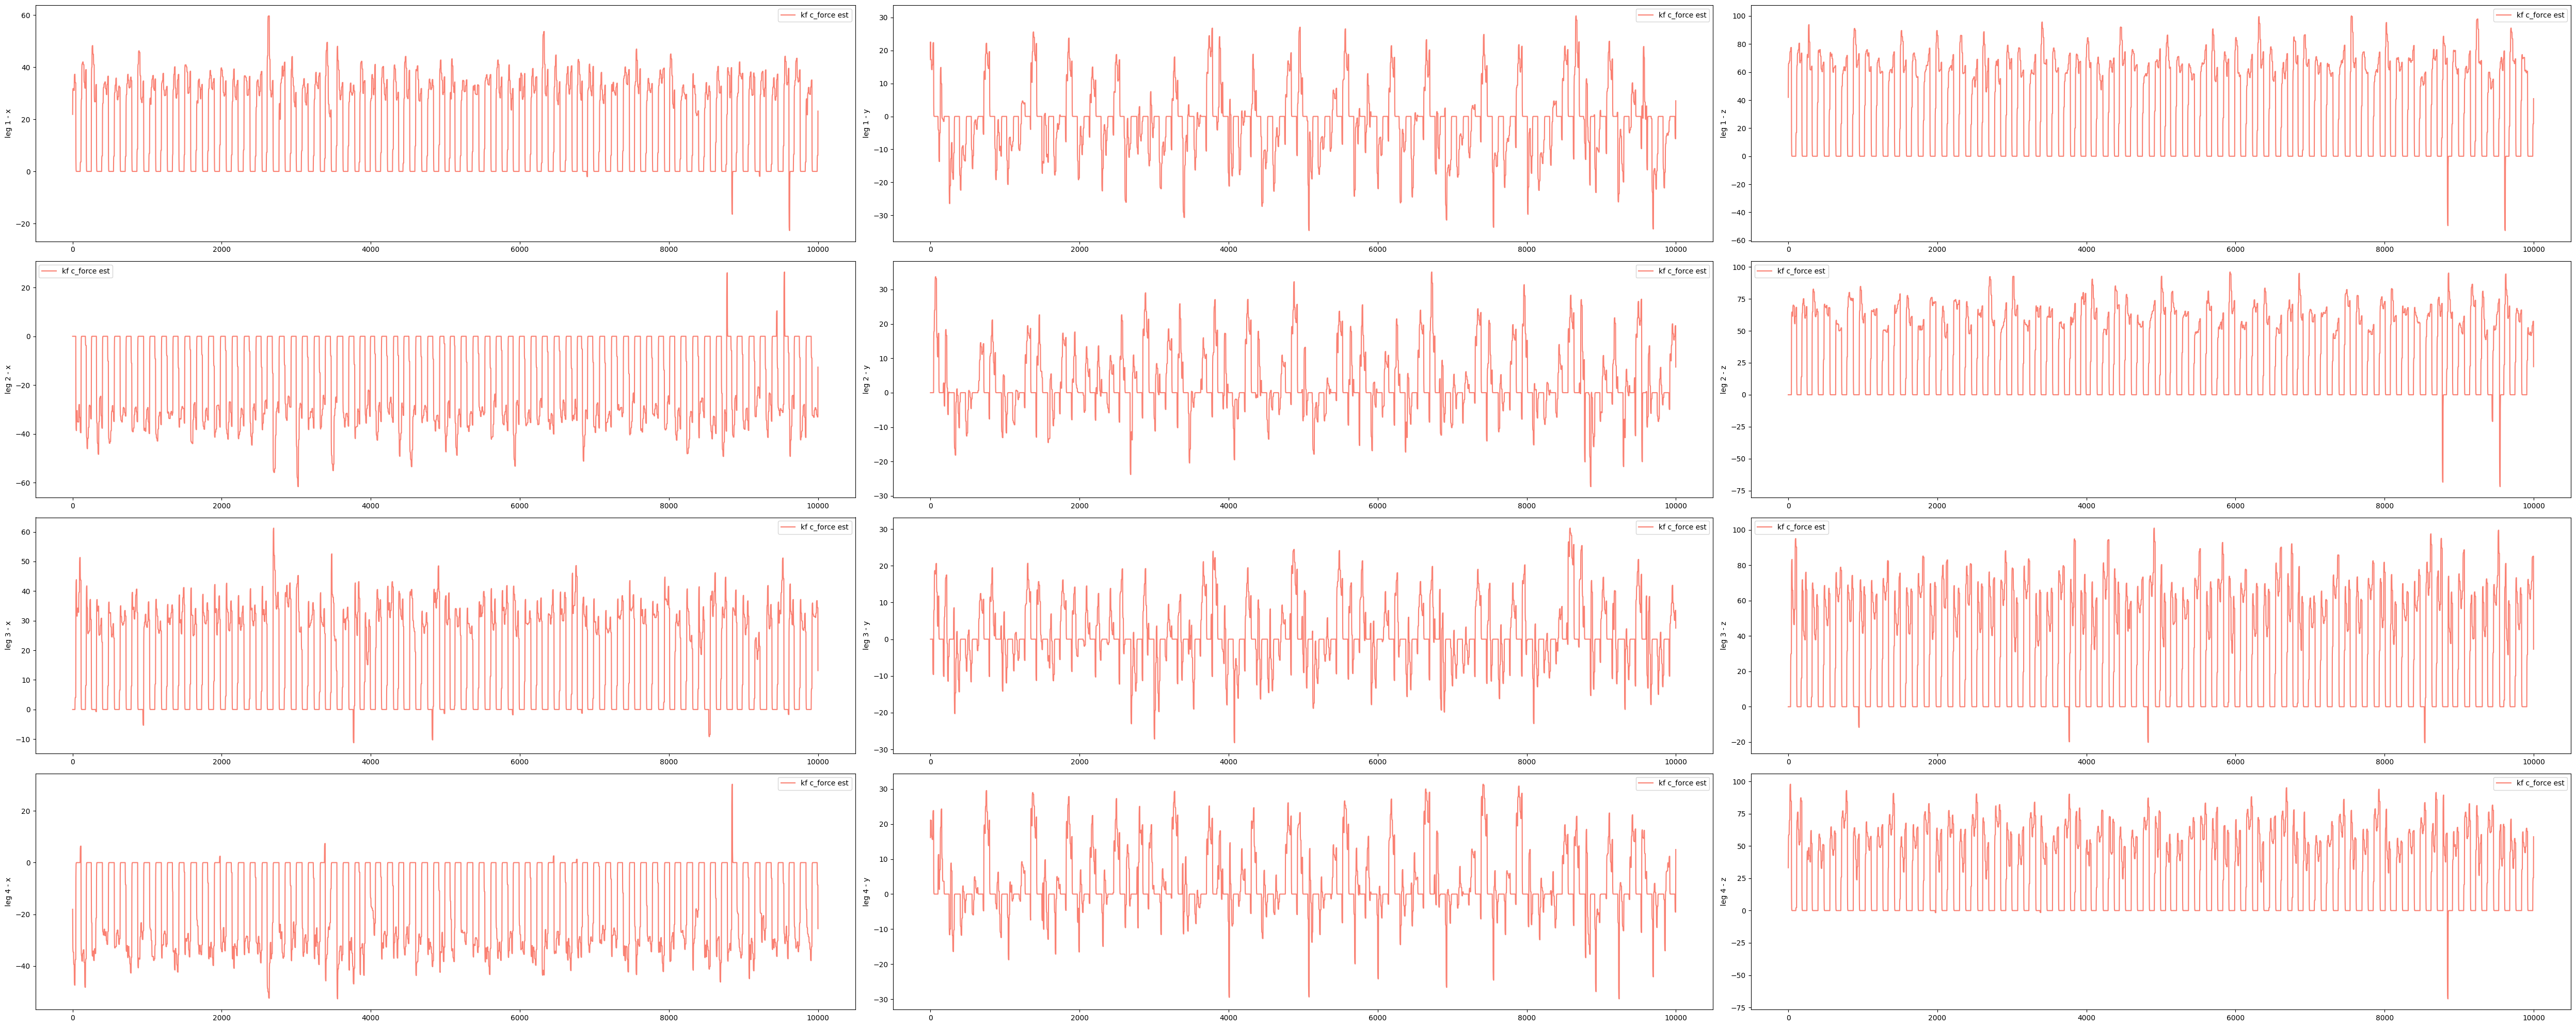

In [17]:
fig, axes = plt.subplots(4, 3, figsize=(50,20))

c_force_est = results_leg_kilo_est["c_force_update"]
start = 0
end = 10000

leg_labels = np.arange(start=1, stop=5)
force_labels = ['x', 'y', 'z']
for i in range(4):
    for j in range(3):
        axes[i, j].plot(np.arange(end-start), c_force_est[start:end, i, j], label="kf c_force est", color="salmon")
        axes[i, j].set_ylabel(f'leg {leg_labels[i]} - {force_labels[j]}')
        axes[i, j].legend()

plt.tight_layout()
plt.show()